# 04 — Age patterns in GSS Jewish identification, 1972–2024

Notebook 02 found the crude share of adults who are Jewish by religion
drifting down from ~2.3% to ~1.7%. **Hypothesis:** the crude decline
corresponds to an aging Jewish population — age-specific shares falling at
young ages while holding up at older ages — rather than a uniform decline.
(Or it might just be noise.)

The yearly Jewish subsample (~40 respondents) cannot support age detail, so
rounds are pooled into four ~13-year **eras** (1972–84, 1985–98, 1999–2011,
2012–24) and four **age groups** (18–34, 35–49, 50–64, 65+), giving 46–139
Jewish respondents per cell. The plots follow the age-profile style of
[`nsduh_opioid_prevalence/04_age_period_cohort.ipynb`](../nsduh_opioid_prevalence/04_age_period_cohort.ipynb):
age groups on the x-axis, era estimates spread within each age slot.
Weighting and Wilson CIs on the Kish effective n as in notebook 02.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

DATA = os.path.abspath(os.path.join('..', 'data'))
df = pd.read_parquet(os.path.join(DATA, 'derived', 'gss_jewish_identity.parquet'))

v = df[df.relig.notna() & df.wtssps.notna() & df.age.notna()].copy()
v['jbr'] = v.relig == 'jewish'

ERA_LABELS = ['1972-84', '1985-98', '1999-2011', '2012-24']
v['era'] = pd.cut(v.year, [1972, 1985, 1999, 2012, 2025],
                  labels=ERA_LABELS, right=False)
AGE_LABELS = ['18-34', '35-49', '50-64', '65+']
v['ageg'] = pd.cut(v.age, [18, 35, 50, 65, 200], labels=AGE_LABELS, right=False)

def weighted_share(g, num_col='jbr'):
    """Weighted share with Wilson 95% CI on the Kish effective sample size."""
    w = g['wtssps'].to_numpy()
    x = g[num_col].to_numpy().astype(float)
    p = (w * x).sum() / w.sum()
    n_eff = w.sum() ** 2 / (w ** 2).sum()
    z = 1.959964
    denom = 1 + z**2 / n_eff
    center = (p + z**2 / (2 * n_eff)) / denom
    half = z * np.sqrt(p * (1 - p) / n_eff + z**2 / (4 * n_eff**2)) / denom
    return pd.Series({'share': p, 'lo': center - half, 'hi': center + half,
                      'n': len(g), 'n_num': int(x.sum())})

cell = v.groupby(['era', 'ageg'], observed=True).apply(weighted_share).unstack('ageg')
cell.xs('n_num', axis=1).astype(int)

ageg,18-34,35-49,50-64,65+
era,,,,
1972-84,121,83,101,80
1985-98,98,136,87,90
1999-2011,64,83,89,83
2012-24,46,59,90,139


Every cell holds 46–139 Jewish respondents — thin, but enough for the
CIs to separate where the pattern is real.

## Age profile by era


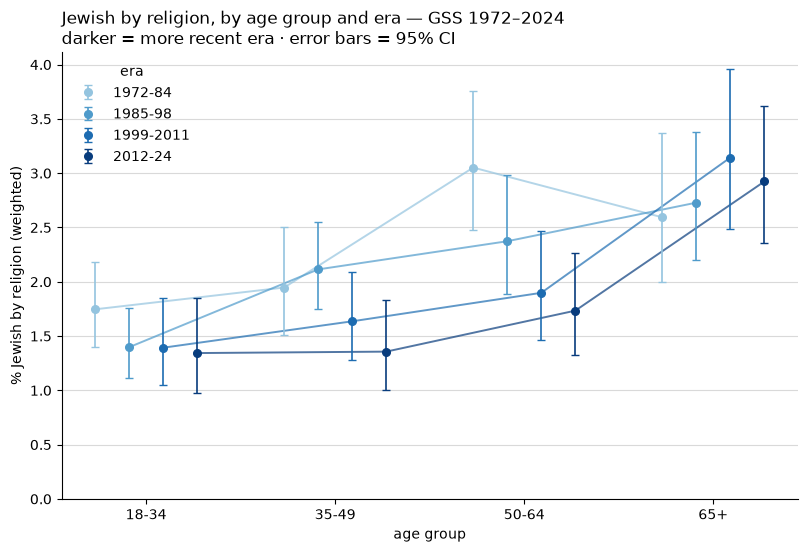

In [2]:
# eras are ordered, so encode them as a sequential single-hue ramp
ERA_COLORS = dict(zip(ERA_LABELS, plt.cm.Blues(np.linspace(0.4, 0.95, 4))))
GRID = dict(color='0.85', linewidth=0.8)

est = v.groupby(['era', 'ageg'], observed=True).apply(weighted_share).reset_index()
age_pos = {a: i for i, a in enumerate(AGE_LABELS)}
offsets = dict(zip(ERA_LABELS, [-0.27, -0.09, 0.09, 0.27]))

fig, ax = plt.subplots(figsize=(9.5, 5.8))
for era in ERA_LABELS:
    d = est[est.era == era].set_index('ageg').reindex(AGE_LABELS)
    x = np.array([age_pos[a] + offsets[era] for a in AGE_LABELS])
    y, lo, hi = 100 * d.share, 100 * d.lo, 100 * d.hi
    ax.plot(x, y, '-', color=ERA_COLORS[era], lw=1.4, alpha=0.7, zorder=2)
    ax.errorbar(x, y, yerr=[y - lo, hi - y], fmt='o', ms=5.5,
                color=ERA_COLORS[era], elinewidth=1.2, capsize=3,
                label=era, zorder=3)

ax.set_xticks(range(len(AGE_LABELS)), AGE_LABELS)
ax.set_xlabel('age group')
ax.set_ylabel('% Jewish by religion (weighted)')
ax.set_ylim(0, None)
ax.set_title('Jewish by religion, by age group and era — GSS 1972–2024\n'
             'darker = more recent era · error bars = 95% CI', loc='left')
ax.legend(frameon=False, title='era', loc='upper left')
ax.grid(axis='y', **GRID)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

**The age gradient reversed.** In 1972–84 the profile was fairly flat —
if anything highest at 50–64 (3.1%). Era by era the under-50 shares slid
(18–34: 1.8% → 1.3%; 35–49: 2.0% → 1.4%; 50–64: 3.1% → 1.7%) while the 65+
share **rose** (2.6% → ~3%). By 2012–24 the profile is steeply age-graded:
Jewish-by-religion adults are more than twice as common at 65+ as under 50.
The CIs separate at the ends of the profile, so this is not noise.

## Is the Jewish population aging faster than everyone else?


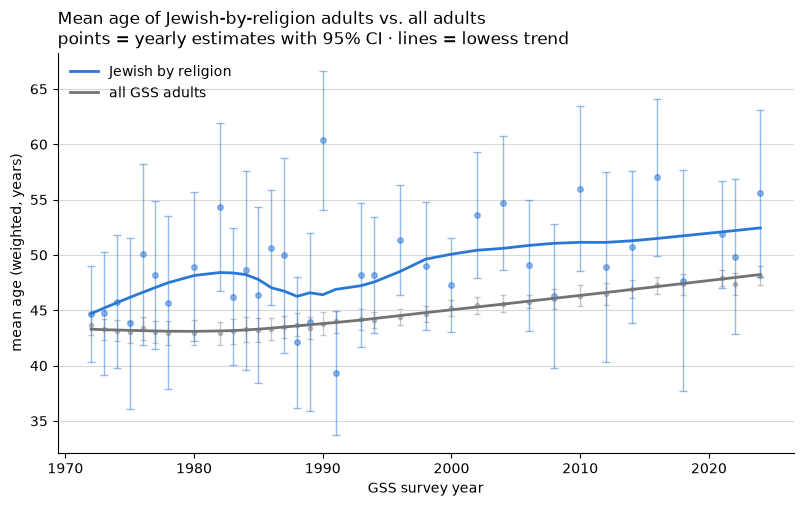

In [3]:
def wmean_age(g):
    w, a = g.wtssps.to_numpy(), g.age.to_numpy()
    m = (w * a).sum() / w.sum()
    n_eff = w.sum() ** 2 / (w ** 2).sum()
    sd = np.sqrt((w * (a - m) ** 2).sum() / w.sum())
    return pd.Series({'mean_age': m, 'se': sd / np.sqrt(n_eff)})

ma_jew = v[v.jbr].groupby('year').apply(wmean_age, include_groups=False)
ma_all = v.groupby('year').apply(wmean_age, include_groups=False)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
c_jew, c_all = '#2a78d6', '0.45'

ax.errorbar(ma_jew.index, ma_jew.mean_age, yerr=1.96 * ma_jew.se, fmt='o',
            ms=4, color=c_jew, elinewidth=1, capsize=3, alpha=0.5, zorder=2)
s = lowess(ma_jew.mean_age, ma_jew.index.to_numpy(), frac=0.4)
ax.plot(s[:, 0], s[:, 1], color=c_jew, lw=2, zorder=3,
        label='Jewish by religion')

ax.errorbar(ma_all.index, ma_all.mean_age, yerr=1.96 * ma_all.se, fmt='o',
            ms=3, color=c_all, elinewidth=1, capsize=2, alpha=0.4, zorder=1)
s = lowess(ma_all.mean_age, ma_all.index.to_numpy(), frac=0.4)
ax.plot(s[:, 0], s[:, 1], color=c_all, lw=2, zorder=3, label='all GSS adults')

ax.set_xlabel('GSS survey year')
ax.set_ylabel('mean age (weighted, years)')
ax.set_title('Mean age of Jewish-by-religion adults vs. all adults\n'
             'points = yearly estimates with 95% CI · lines = lowess trend',
             loc='left')
ax.legend(frameon=False, loc='upper left')
ax.grid(axis='y', **GRID)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

In [4]:
aging = pd.DataFrame({
    'mean age, Jewish': v[v.jbr].groupby('era', observed=True).apply(
        wmean_age, include_groups=False).mean_age,
    'mean age, all adults': v.groupby('era', observed=True).apply(
        wmean_age, include_groups=False).mean_age,
    '% 65+, Jewish': 100 * v[v.jbr].assign(o=v.ageg == '65+').groupby(
        'era', observed=True).apply(weighted_share, num_col='o').share,
    '% 65+, all adults': 100 * v.assign(o=v.ageg == '65+').groupby(
        'era', observed=True).apply(weighted_share, num_col='o').share,
})
aging.round(1)

,"mean age, Jewish","mean age, all adults","% 65+, Jewish","% 65+, all adults"
era,,,,
1972-84,47.1,43.2,17.6,14.9
1985-98,48.3,44.0,22.0,16.1
1999-2011,50.7,45.7,27.8,16.5
2012-24,52.2,47.4,33.9,20.5


Both trends drift upward — the whole adult population is aging — but the
Jewish-by-religion line pulls away: the mean-age gap roughly doubles
(≈47 vs 43 in the 1970s–80s; ≈52 vs 47 in 2012–24), and the share of
Jewish-by-religion adults who are 65+ climbs from 18% to **34%**, versus 15%
→ 21% among all adults.

## The cohort view

Age-specific decline with stable old-age prevalence is the signature of
**cohort replacement**: high-identification birth cohorts aging out of the
young columns and into 65+, replaced by lower-identification cohorts. Birth
cohort = survey year − age, pooled across all 34 rounds.


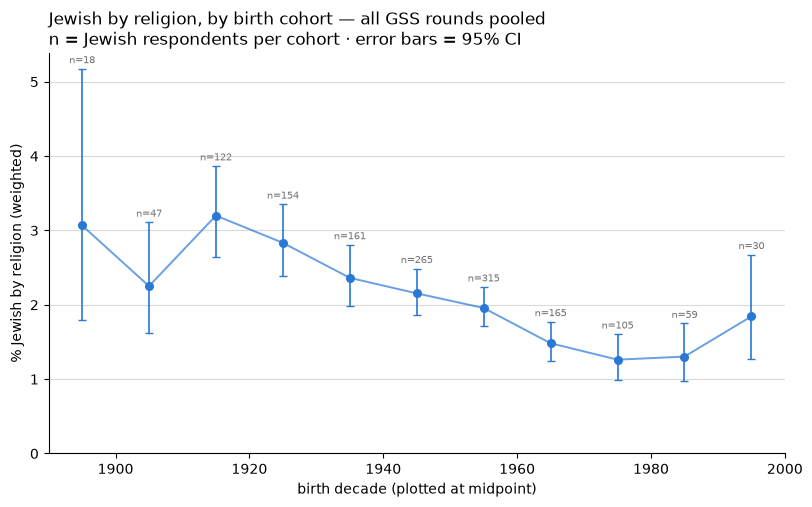

In [5]:
v['cohort'] = ((v.year - v.age) // 10 * 10).astype(int)
coh = v[(v.cohort >= 1890) & (v.cohort <= 1990)].groupby('cohort').apply(
    weighted_share, include_groups=False)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
y, lo, hi = 100 * coh.share, 100 * coh.lo, 100 * coh.hi
ax.errorbar(coh.index + 5, y, yerr=[y - lo, hi - y], fmt='o', ms=5.5,
            color='#2a78d6', elinewidth=1.2, capsize=3, zorder=3)
ax.plot(coh.index + 5, y, '-', color='#2a78d6', lw=1.4, alpha=0.7, zorder=2)

for c_, r in coh.iterrows():
    ax.annotate(f"n={r.n_num:.0f}", (c_ + 5, 100 * r.hi), xytext=(0, 4),
                textcoords='offset points', ha='center', fontsize=7.5,
                color='0.45')

ax.set_xlabel('birth decade (plotted at midpoint)')
ax.set_ylabel('% Jewish by religion (weighted)')
ax.set_ylim(0, None)
ax.set_title('Jewish by religion, by birth cohort — all GSS rounds pooled\n'
             'n = Jewish respondents per cohort · error bars = 95% CI',
             loc='left')
ax.grid(axis='y', **GRID)
ax.spines[['top', 'right']].set_visible(False)
plt.show()

## Verdict on the hypothesis

**Supported — this is structure, not noise.** Three mutually consistent
views say the crude decline is a cohort/aging story:

1. **Age-specific shares** fell only under age 65; at 65+ they rose. The
   crude decline is concentrated where the low-identification cohorts have
   arrived.
2. **The Jewish-by-religion population aged much faster** than the adult
   population as a whole (65+ share: 18% → 34%, vs 15% → 21%).
3. **The birth-cohort gradient is monotone** from the 1910s cohort (3.2%)
   through the 1970s cohort (1.3%) — with pooled cohort cells of 100–300
   Jewish respondents, tight enough CIs that the trend is unambiguous.
   The apparent uptick for the 1990s cohort (1.8%, n=30) is the one place
   that could still be noise — though it is where Orthodox fertility would
   first appear, so worth re-checking as rounds accumulate.

Two caveats. Because the 65+ share rose while under-50 shares fell, the
*crude* trend actually understates the within-age decline at younger ages.
And this is identification by *religion*: the cohort slide partly reflects
younger Jews relabeling as "no religion" (notebook 02's rising
raised-Jewish-now-none share) rather than disappearance — Pew's net-Jewish
count is correspondingly more stable across cohorts.
